In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

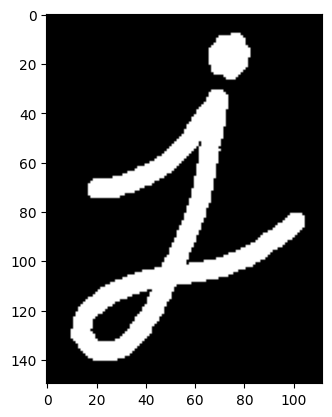

In [3]:
img_grey = cv2.imread(r'j.png')
plt.imshow(img_grey)

In [4]:
np.unique(img_grey)

array([  0, 255], dtype=uint8)

In [5]:
th = 100
im = img_grey>th

In [6]:
print(np.unique(im))

[False  True]


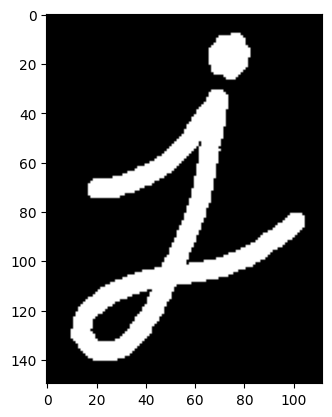

In [7]:
_, binary_img = cv2.threshold(img_grey, 127, 255, cv2.THRESH_BINARY)
plt.imshow(binary_img)


In [8]:
k_r = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))

In [9]:
k_e = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))

In [10]:
k_c = cv2.getStructuringElement(cv2.MORPH_CROSS,(5,5))

# Erosion

In [11]:
E_r = cv2.erode(binary_img, k_r)
E_e = cv2.erode(binary_img, k_e)
E_c = cv2.erode(binary_img, k_c)

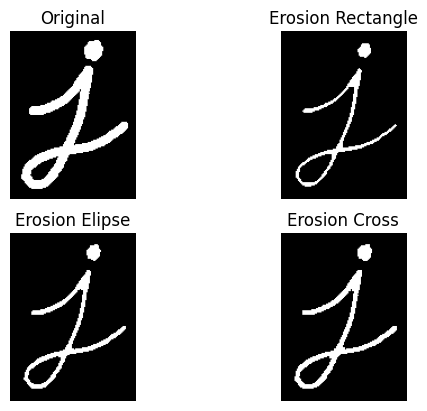

In [12]:
plt.subplot(221)
plt.imshow(binary_img)
plt.title('Original')
plt.axis('off')
plt.subplot(222)
plt.title('Erosion Rectangle')
plt.axis('off')
plt.imshow(E_r)
plt.subplot(223)
plt.title('Erosion Elipse')
plt.axis('off')
plt.imshow(E_e)
plt.subplot(224)
plt.title('Erosion Cross')
plt.axis('off')
plt.imshow(E_c)

In [13]:
print(np.sum(E_e - E_c))

510


# Dilation 

In [14]:
D_r = cv2.dilate(binary_img, k_r)
D_e = cv2.dilate(binary_img, k_e)
D_c = cv2.dilate(binary_img, k_c)

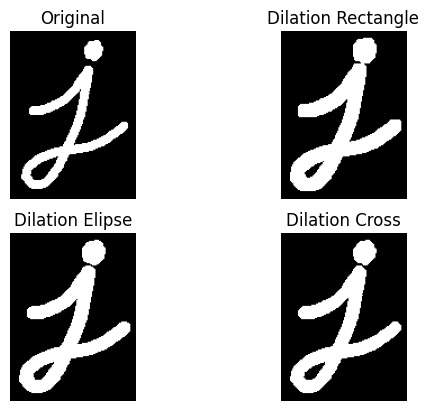

In [15]:
plt.subplot(221)
plt.imshow(binary_img)
plt.title('Original')
plt.axis('off')
plt.subplot(222)
plt.title('Dilation Rectangle')
plt.axis('off')
plt.imshow(D_r)
plt.subplot(223)
plt.title('Dilation Elipse')
plt.axis('off')
plt.imshow(D_e)
plt.subplot(224)
plt.title('Dilation Cross')
plt.axis('off')
plt.imshow(D_c)

In [16]:
binary_img.dtype

dtype('uint8')

In [17]:
im_bool = np.array(binary_img[:,:,0], dtype=np.bool)

In [18]:
noise = np.random.rand(im_bool.shape[0],im_bool.shape[1])

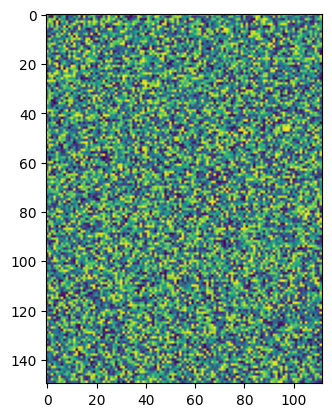

In [19]:
plt.imshow(noise)

In [20]:
noise

array([[0.57920248, 0.46465455, 0.14254013, ..., 0.39119939, 0.07319304,
        0.80694087],
       [0.71290447, 0.06879279, 0.01283396, ..., 0.59007696, 0.38735195,
        0.92189812],
       [0.43254894, 0.85895343, 0.7776501 , ..., 0.53281112, 0.77405822,
        0.73095762],
       ...,
       [0.5186802 , 0.08047874, 0.25628335, ..., 0.80307556, 0.61279045,
        0.92086   ],
       [0.21397645, 0.16237077, 0.84763516, ..., 0.69517341, 0.23548237,
        0.42231459],
       [0.2128579 , 0.33851118, 0.30040075, ..., 0.23962022, 0.1180424 ,
        0.07305808]], shape=(150, 112))

In [21]:
noise_binary = noise>0.99

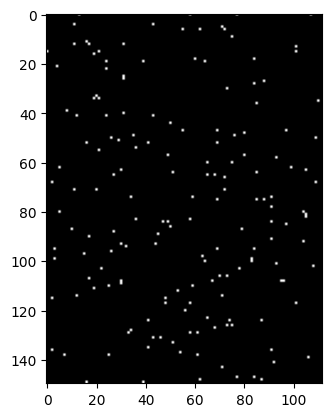

In [22]:
plt.imshow(noise_binary,cmap='grey')

In [23]:
img_noise = im_bool | noise_binary

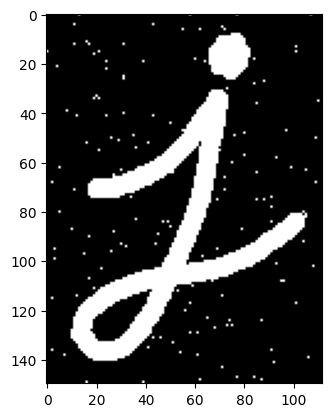

In [24]:
plt.imshow(img_noise, cmap='grey')

# Opening

In [25]:
o_r = cv2.morphologyEx(np.float32(img_noise),cv2.MORPH_OPEN,k_r)

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

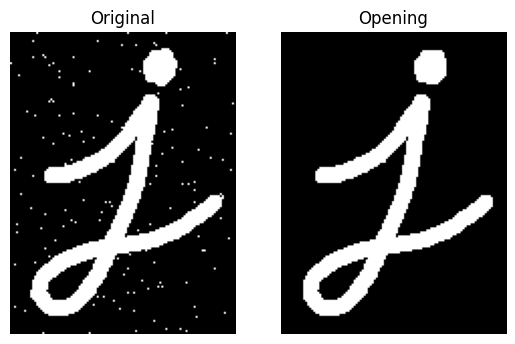

In [33]:
plt.subplot(121)
plt.imshow(img_noise,cmap='grey')
plt.title('Original')
plt.axis('off')
plt.subplot(122)
plt.imshow(o_r,cmap='grey')
plt.title('Opening')
plt.axis('off')

In [27]:
E_r = cv2.erode(np.float32(img_noise),k_r)

In [28]:
D_r = cv2.dilate(E_r,k_r)

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

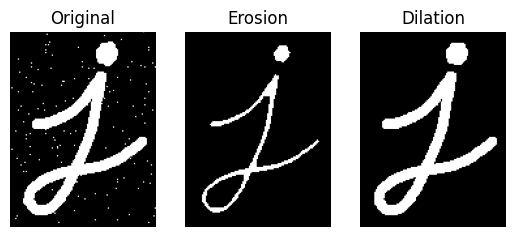

In [29]:
plt.subplot(131)
plt.imshow(img_noise,cmap='grey')
plt.title('Original')
plt.axis('off')
plt.subplot(132)
plt.imshow(E_r,cmap='grey')
plt.title('Erosion')
plt.axis('off')
plt.subplot(133)
plt.imshow(D_r,cmap='grey')
plt.title('Dilation')
plt.axis('off')

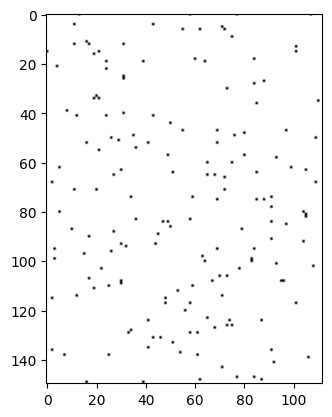

In [27]:
noise_binary = noise<0.99
plt.imshow(noise_binary, cmap='grey')

In [28]:
noise_img = im_bool & noise_binary

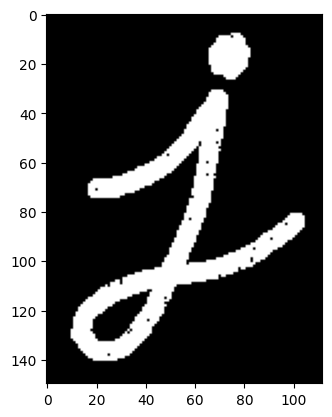

In [29]:
plt.imshow(noise_img, cmap='grey')

In [30]:
C_r = cv2.morphologyEx(np.float32(noise_img),cv2.MORPH_CLOSE,k_r)

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

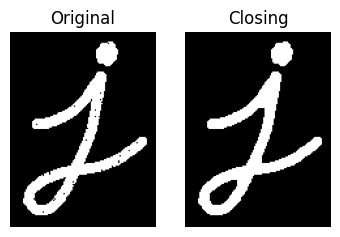

In [32]:
plt.subplot(131)
plt.imshow(noise_img,cmap='grey')
plt.title('Original')
plt.axis('off')
plt.subplot(132)
plt.imshow(C_r,cmap='grey')
plt.title('Closing')
plt.axis('off')


(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

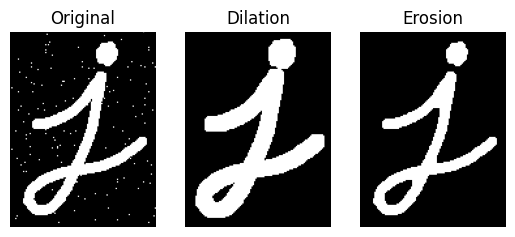

In [35]:
D_r = cv2.dilate(np.float32(noise_img),k_r)
E_r = cv2.erode(D_r,k_r)
plt.subplot(131)
plt.imshow(img_noise,cmap='grey')
plt.title('Original')
plt.axis('off')
plt.subplot(132)
plt.imshow(D_r,cmap='grey')
plt.title('Dilation')
plt.axis('off')
plt.subplot(133)
plt.imshow(E_r,cmap='grey')
plt.title('Erosion')
plt.axis('off')

# Gradient

In [41]:
Grad = cv2.morphologyEx(binary_img,cv2.MORPH_GRADIENT,k_r)

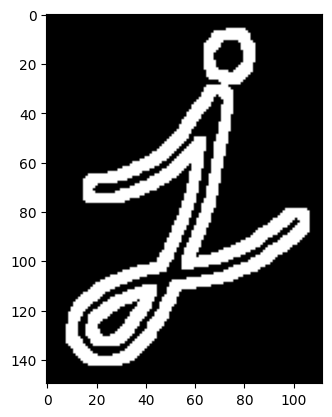

In [42]:
plt.imshow(Grad,cmap='grey')

In [43]:
D_r = cv2.dilate(binary_img, k_r)
E_r = cv2.erode(binary_img, k_r)
Gradient = D_r - E_r

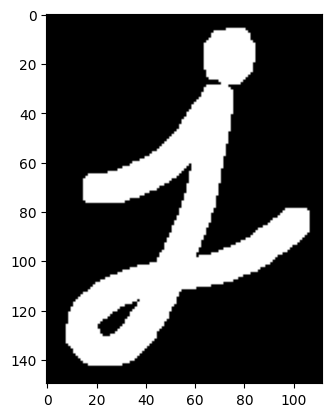

In [46]:
plt.imshow(D_r-E_r, cmap='grey')

# Top Hat


In [55]:
top_hat = cv2.morphologyEx(E_r,cv2.MORPH_TOPHAT,k_r)

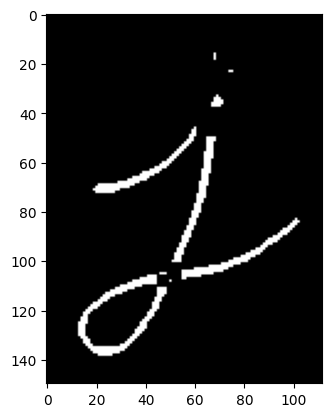

In [56]:
plt.imshow(top_hat, cmap='grey')

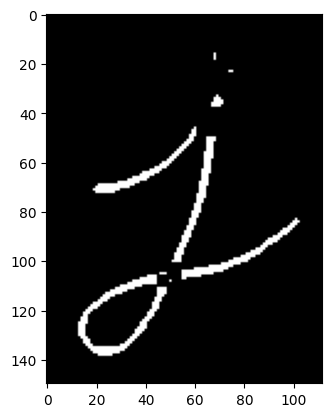

In [59]:
o_r = cv2.morphologyEx(E_r[:,:,0],cv2.MORPH_OPEN,k_r)
plt.imshow(E_r[:,:,0]-o_r, cmap='grey')

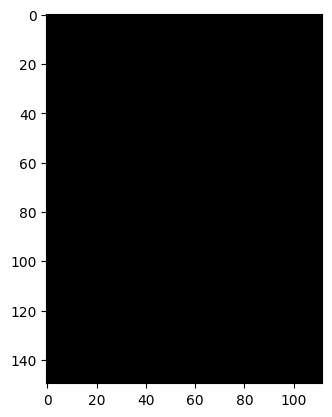